# Model Comparison: ARIMA-GARCH vs LSTM

This notebook computes and visualizes the forecasting accuracy of the two models
on held-out data, using the saved outputs from each training pipeline:

- `Arima-Garch/results/Arima_Garch_Forecast.xlsx` — ARIMA-GARCH return forecasts
- `Lstm/saved_models/predictions.csv` — LSTM v2 (technical + sentiment + ARIMA-GARCH fusion) price-level forecasts

See the main [README](../README.md) for the full writeup. This notebook exists so
the numbers there are reproducible, not just asserted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 5)

## 1. ARIMA-GARCH

Loading the saved forecast file. Only rows with both an actual value and a
forecast are evaluated (the model was only run forward on a short window —
see the README for why that matters).

In [2]:
ag_df = pd.read_excel('../Arima-Garch/results/Arima_Garch_Forecast.xlsx')
ag_forecasts = ag_df.dropna(subset=['Actual', 'Forecast_Mean']).copy()

print(f"Total rows in file: {len(ag_df)}")
print(f"Rows with a forecast: {len(ag_forecasts)}")
ag_forecasts[['DATE', 'Actual', 'Forecast_Mean', 'Forecast_Std']].head()

Total rows in file: 7850
Rows with a forecast: 47


,DATE,Actual,Forecast_Mean,Forecast_Std
7802,2024-12-19 09:35:00,-0.00004,0.00039,0.00069
7803,2024-12-19 09:36:00,-0.00148,0.00041,0.00061
7804,2024-12-19 09:37:00,-0.00110,0.00029,0.00057
7805,2024-12-19 09:38:00,0.00089,-0.00019,0.00094
7806,2024-12-19 09:39:00,0.00013,-0.00049,0.00092


In [3]:
actual = ag_forecasts['Actual'].values
pred = ag_forecasts['Forecast_Mean'].values

ag_rmse = np.sqrt(np.mean((actual - pred) ** 2))
ag_mae = np.mean(np.abs(actual - pred))
ag_dir_acc = np.mean(np.sign(actual) == np.sign(pred))

print(f"RMSE (returns):          {ag_rmse:.5f}")
print(f"MAE (returns):           {ag_mae:.5f}")
print(f"Directional accuracy:    {ag_dir_acc:.1%}")

RMSE (returns):          0.00083
MAE (returns):           0.00065
Directional accuracy:    44.7%


Plotting actual vs. predicted returns over the forecast window. If the model
had real directional skill, the predicted line would consistently land on the
same side of zero as the actual line — visually, it doesn't.

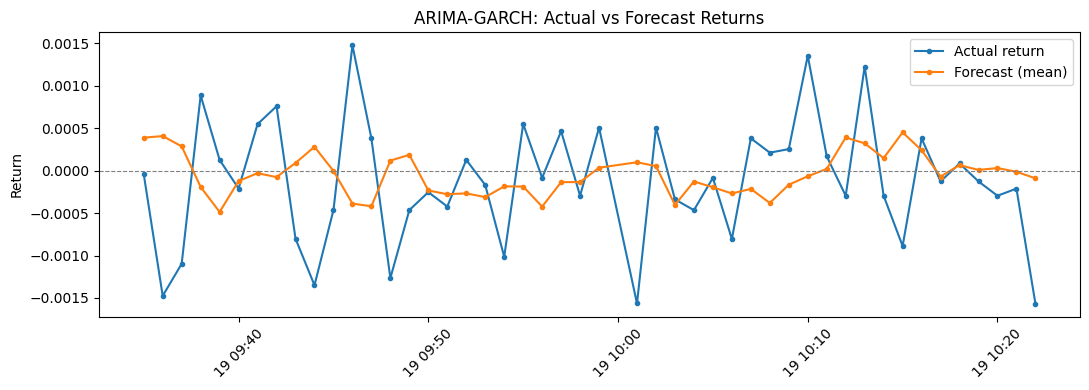

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ag_forecasts['DATE'], actual, label='Actual return', marker='o', markersize=3)
ax.plot(ag_forecasts['DATE'], pred, label='Forecast (mean)', marker='o', markersize=3)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('ARIMA-GARCH: Actual vs Forecast Returns')
ax.set_ylabel('Return')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. LSTM v2 (technical indicators + sentiment + ARIMA-GARCH forecast)

This is the only trained/saved LSTM variant. It predicts price level directly
(not returns), so metrics aren't directly comparable to ARIMA-GARCH above —
each model is evaluated on its own terms first, then both are compared on the
one metric that *is* comparable across both: directional accuracy.

In [5]:
lstm_df = pd.read_csv('../Lstm/saved_models/predictions.csv')
print(f"Number of predictions: {len(lstm_df)}")
lstm_df.head()

Number of predictions: 35


,Actual,Predicted
0,6029.00,6018.8823
1,6031.50,6018.8160
2,6031.25,6019.1143
3,6029.75,6019.2305
4,6029.50,6019.0380


In [6]:
lstm_actual = lstm_df['Actual'].values
lstm_pred = lstm_df['Predicted'].values

lstm_rmse = np.sqrt(np.mean((lstm_actual - lstm_pred) ** 2))
lstm_mae = np.mean(np.abs(lstm_actual - lstm_pred))
lstm_mape = np.mean(np.abs((lstm_actual - lstm_pred) / lstm_actual)) * 100

# Directional accuracy: did the model get the sign of the *change* right?
actual_diff = np.diff(lstm_actual)
pred_diff = np.diff(lstm_pred)
lstm_dir_acc = np.mean(np.sign(actual_diff) == np.sign(pred_diff))

print(f"RMSE (price level):   {lstm_rmse:.4f}")
print(f"MAE (price level):    {lstm_mae:.4f}")
print(f"MAPE:                 {lstm_mape:.4f}%")
print(f"Directional accuracy: {lstm_dir_acc:.1%}")

RMSE (price level):   11.1185
MAE (price level):    11.0293
MAPE:                 0.1829%
Directional accuracy: 38.2%


Plotting actual vs. predicted price level. Note the predicted series is much
flatter than the actual series — the model is tracking the rough price band but
not the bar-to-bar wiggles, which is exactly why directional accuracy is poor
even though the price-level error (MAPE) looks small.

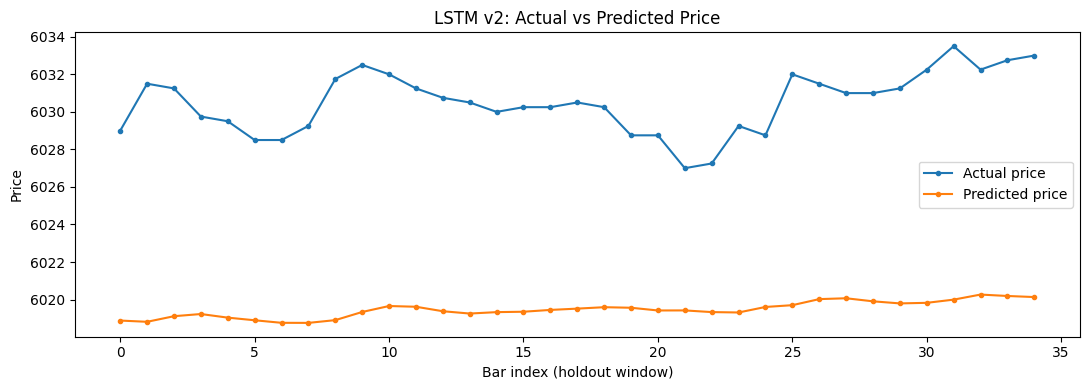

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lstm_actual, label='Actual price', marker='o', markersize=3)
ax.plot(lstm_pred, label='Predicted price', marker='o', markersize=3)
ax.set_title('LSTM v2: Actual vs Predicted Price')
ax.set_xlabel('Bar index (holdout window)')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Head-to-head: directional accuracy

Directional accuracy — did the model correctly predict whether the price/return
would go up or down — is the one metric that's meaningful across both models,
since it doesn't depend on the units being forecast (returns vs. price level).

In [8]:
comparison = pd.DataFrame({
    'Model': ['ARIMA-GARCH', 'LSTM v2'],
    'Directional Accuracy': [ag_dir_acc, lstm_dir_acc],
    'N (holdout points)': [len(ag_forecasts), len(lstm_df) - 1],
})
comparison['Directional Accuracy'] = comparison['Directional Accuracy'].map(lambda x: f"{x:.1%}")
comparison

,Model,Directional Accuracy,N (holdout points)
0,ARIMA-GARCH,44.7%,47
1,LSTM v2,38.2%,34


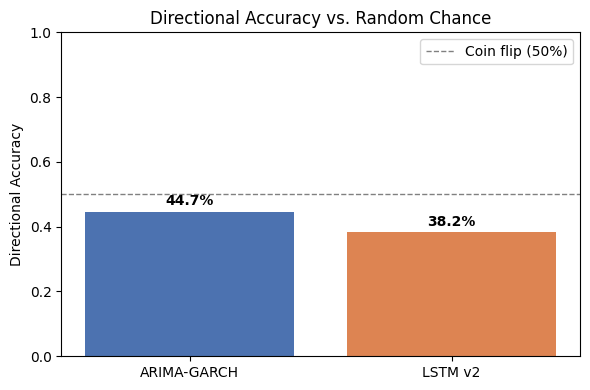

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
models = ['ARIMA-GARCH', 'LSTM v2']
accs = [ag_dir_acc, lstm_dir_acc]
colors = ['#4C72B0', '#DD8452']

bars = ax.bar(models, accs, color=colors)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Coin flip (50%)')
ax.set_ylim(0, 1)
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy vs. Random Chance')
ax.legend()

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.1%}",
            ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Takeaway

Both models fall below the 50% coin-flip line on directional accuracy at this
1-minute horizon on S&P 500 futures. This is consistent with market efficiency
at high frequency on a liquid instrument — see the README's
[Results](../README.md#results) section for the fuller discussion, including why
the ARIMA-GARCH residual diagnostics still look "good" (capturing linear
structure in returns) despite poor directional accuracy (very little of that
structure translates into next-bar direction).

**Caveat:** sample sizes here are small (47 and 34 holdout points respectively).
These are directional, not statistically definitive, comparisons — a fuller
walk-forward backtest across the short/medium/long horizons in the
[Next steps](../README.md#next-steps) section would be needed before drawing
strong conclusions.